计算得到的特征值： [ 3.23632188e+01-4.59335341e+01j  5.76248075e-01+4.66778493e+01j
 -3.16221924e+01-7.20569348e+00j  4.14127309e-14+1.07895663e-14j
  0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
  0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
  0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j]
已知特征值： [1.+1.j 2.-1.j 3.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+

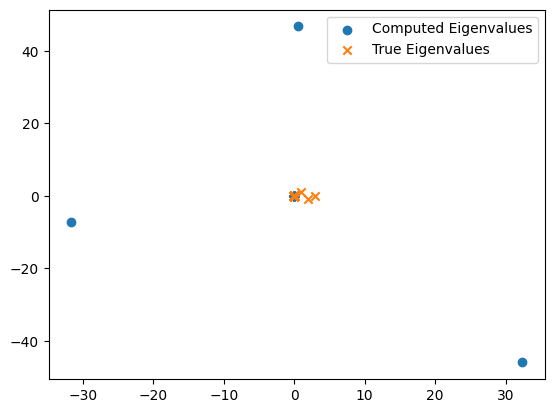

In [39]:
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt

# 定义生成稀疏矩阵的函数，通过已知特征值和特征向量
def generate_sparse_matrix(n, eigenvalues, eigenvectors):
    """
    生成一个稀疏矩阵，其特征值和特征向量已知
    n: 矩阵的大小
    eigenvalues: 特征值
    eigenvectors: 特征向量矩阵
    """
    D = np.diag(eigenvalues)  # 构造特征值矩阵
    A = eigenvectors @ D @ eigenvectors.T  # 生成矩阵 A = V * D * V.T
    return sp.csr_matrix(A)  # 返回稀疏矩阵

# Arnoldi迭代函数
def arnoldi_iteration(A, b, m):
    """
    实现Arnoldi迭代，用于构造Krylov子空间
    A: 输入矩阵
    b: 初始向量
    m: 迭代次数
    """
    n = A.shape[0]
    H = np.zeros((m, m), dtype=complex)  # Hessenberg矩阵
    V = np.zeros((n, m+1), dtype=complex)  # 正交基
    V[:, 0] = b / np.linalg.norm(b)  # 初始化V_0

    for j in range(m):
        # 对当前列V_j进行矩阵-向量乘法（使用稀疏矩阵乘法）
        w = A @ V[:, j]

        # 进行正交化
        for i in range(j+1):
            H[i, j] = np.vdot(V[:, i], w)
            w = w - H[i, j] * V[:, i]

        H[j+1, j] = np.linalg.norm(w)
        if H[j+1, j] > 1e-10:  # 防止除以0
            V[:, j+1] = w / H[j+1, j]
        else:
            break  # 如果矩阵列已经完备，可以提前终止

    return H[:m, :m], V[:, :m]  # 返回Hessenberg矩阵和正交基

# QR算法函数
def qr_algorithm(H, max_iter=1000):
    """
    QR算法，迭代求解Hessenberg矩阵的特征值
    H: Hessenberg矩阵
    max_iter: 最大迭代次数
    """
    n = H.shape[0]
    for _ in range(max_iter):
        Q, R = np.linalg.qr(H)  # QR分解
        H = R @ Q  # 更新H矩阵
    # 返回矩阵的对角线元素，即特征值
    return np.diag(H)

# 验证结果函数
def validate_result(A, eigenvalues, eigenvectors, computed_eigenvalues, computed_eigenvectors):
    """
    验证Arnoldi迭代与QR分解结果的准确性
    A: 原始矩阵
    eigenvalues: 已知的特征值
    eigenvectors: 已知的特征向量
    computed_eigenvalues: Arnoldi + QR求得的特征值
    computed_eigenvectors: Arnoldi + QR求得的特征向量
    """
    print("已知特征值：", eigenvalues)
    print("计算得到的特征值：", computed_eigenvalues)

    # 计算特征向量的误差
    errors = []
    for i in range(len(computed_eigenvalues)):
        error = np.linalg.norm(A @ computed_eigenvectors[:, i] - computed_eigenvalues[i] * computed_eigenvectors[:, i])
        errors.append(error)
    
    print("特征向量误差：", errors)

# 主函数
def main():
    # 矩阵的维度
    n = 100
    m = 10  # Arnoldi迭代的次数

    # 生成一个已知的特征值和特征向量
    eigenvalues = np.array([1 + 1j, 2 - 1j, 3 + 0j] + [0]*97)  # 假设只有前三个非零特征值
    eigenvectors = np.random.randn(n, len(eigenvalues)) + 1j * np.random.randn(n, len(eigenvalues))  # 随机生成特征向量

    # 生成稀疏矩阵
    A = generate_sparse_matrix(n, eigenvalues, eigenvectors)

    # 随机选取初始向量
    b = np.random.randn(n) + 1j * np.random.randn(n)

    # Arnoldi迭代
    H, V = arnoldi_iteration(A, b, m)

    # QR算法求解特征值
    computed_eigenvalues = qr_algorithm(H)

    # 输出计算结果
    print("计算得到的特征值：", computed_eigenvalues)

    # 验证结果
    validate_result(A.toarray(), eigenvalues, eigenvectors, computed_eigenvalues, V)

    # 可视化特征值分布
    plt.scatter(np.real(computed_eigenvalues), np.imag(computed_eigenvalues), label='Computed Eigenvalues')
    plt.scatter(np.real(eigenvalues), np.imag(eigenvalues), label='True Eigenvalues', marker='x')
    plt.legend()
    plt.show()

if __name__ == "__main__":
    main()
